# 情報数学Ⅲ 第2回

### 🔍 利用方法

- このノートブックは**閲覧専用**です。  
  自分のGoogleドライブにコピーを作成してから編集してください。

  1. メニューの「**ファイル → ドライブにコピーを保存**」を選ぶ  
  2. コピーしたノートブックの**ファイル名（左上の"xxxx"）を学籍番号に変更**してください（提出時の識別のため）

---

### 🔧 提出手順

1. Google Colab の右上にある「**共有**」ボタンをクリック  
2. 「**一般的なアクセス**」の設定を「**リンクを知っている全員**」に変更  
3. アクセス権を「**閲覧者**」に設定（⚠️「編集者」にしないこと！）  
4. 表示されるURLをコピー  
5. WebClassの提出フォームに、その**URLを貼り付けて提出**

---

### 💡 補足・注意点

- **「編集者」ではなく「閲覧者」**に設定してください。  
  → 教員が間違ってファイルを上書きしてしまうのを防ぐためです。
- **提出したリンクを自分でも一度開いてみて、ちゃんと共有されているかを確認**してください。

### 参考：ゲームプレイ時間の度数分布表を作る

In [ ]:
# 使用するライブラリのインポート
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install japanize_matplotlib
import japanize_matplotlib # # 日本語表示をするためのライブラリ
import seaborn as sns


In [ ]:
# 辞書のリストを使ってDataFrameを作成する
data = [
    {"プレイ時間/日": 3.0, "年齢": 15, "性別": "男", "都道府県": "新潟県", "血液型": "A"},
    {"プレイ時間/日": 2.5, "年齢": 19, "性別": "女", "都道府県": "東京都", "血液型": "B"},
    {"プレイ時間/日": 4.0, "年齢": 35, "性別": "男", "都道府県": "神奈川県", "血液型": "A"},
    {"プレイ時間/日": 1.5, "年齢": 51, "性別": "男", "都道府県": "新潟県", "血液型": "O"},
    {"プレイ時間/日": 0.5, "年齢": 28, "性別": "女", "都道府県": "長野県", "血液型": "AB"},
    {"プレイ時間/日": 5.5, "年齢": 12, "性別": "男", "都道府県": "東京都", "血液型": "B"},
    {"プレイ時間/日": 1.0, "年齢": 32, "性別": "女", "都道府県": "福島県", "血液型": "A"},
    {"プレイ時間/日": 3.0, "年齢": 48, "性別": "男", "都道府県": "宮城県", "血液型": "O"},
    {"プレイ時間/日": 2.5, "年齢": 25, "性別": "男", "都道府県": "山形県", "血液型": "A"},
    {"プレイ時間/日": 1.5, "年齢": 18, "性別": "女", "都道府県": "新潟県", "血液型": "A"},
]
df = pd.DataFrame(data)
df.head()


,プレイ時間/日,年齢,性別,都道府県,血液型
0,3.0,15,男,新潟県,A
1,2.5,19,女,東京都,B
2,4.0,35,男,神奈川県,A
3,1.5,51,男,新潟県,O
4,0.5,28,女,長野県,AB


In [ ]:
# プレイ時間だけ取り出す
play_time = df["プレイ時間/日"]
play_time.head()

,プレイ時間/日
0,3.0
1,2.5
2,4.0
3,1.5
4,0.5


In [ ]:
# プレイ時間を数える
play_time.value_counts()

,count
プレイ時間/日,
3.0,2
2.5,2
1.5,2
4.0,1
0.5,1
5.5,1
1.0,1


In [ ]:
# 階級の区切りを作る
#bins = [0, 1, 2, 3, 4, 5, 6] # ↓はこれを返す（少ないときは手で書いてもよい）
bins = np.arange(0, 7, 1)
bins


array([0, 1, 2, 3, 4, 5, 6])

In [ ]:
# 度数分布表の作成
play_time.value_counts(bins=bins, sort=False)

,count
"(-0.001, 1.0]",2
"(1.0, 2.0]",2
"(2.0, 3.0]",4
"(3.0, 4.0]",1
"(4.0, 5.0]",0
"(5.0, 6.0]",1


In [ ]:
# 教科書にはない少し便利な関数cut→データの入っている階級を求める
pd.cut(play_time, bins)

,プレイ時間/日
0,"(2, 3]"
1,"(2, 3]"
2,"(3, 4]"
3,"(1, 2]"
4,"(0, 1]"
5,"(5, 6]"
6,"(0, 1]"
7,"(2, 3]"
8,"(2, 3]"
9,"(1, 2]"


In [ ]:
# 区間の端を0以上1未満などにする（cutだとこれが簡単）
pd.cut(play_time, bins, right=False)

,プレイ時間/日
0,"[3, 4)"
1,"[2, 3)"
2,"[4, 5)"
3,"[1, 2)"
4,"[0, 1)"
5,"[5, 6)"
6,"[1, 2)"
7,"[3, 4)"
8,"[2, 3)"
9,"[1, 2)"


In [ ]:
# 度数分布表を作る
pd.cut(play_time, bins, right=False).value_counts()

,count
プレイ時間/日,
"[1, 2)",3
"[2, 3)",2
"[3, 4)",2
"[0, 1)",1
"[4, 5)",1
"[5, 6)",1


In [ ]:
# 度数順じゃなくて階級順で出力する
bin_counts = pd.cut(play_time, bins, right=False).value_counts(sort=False)
bin_counts

,count
プレイ時間/日,
"[0, 1)",1
"[1, 2)",3
"[2, 3)",2
"[3, 4)",2
"[4, 5)",1
"[5, 6)",1


<Axes: xlabel='プレイ時間/日'>

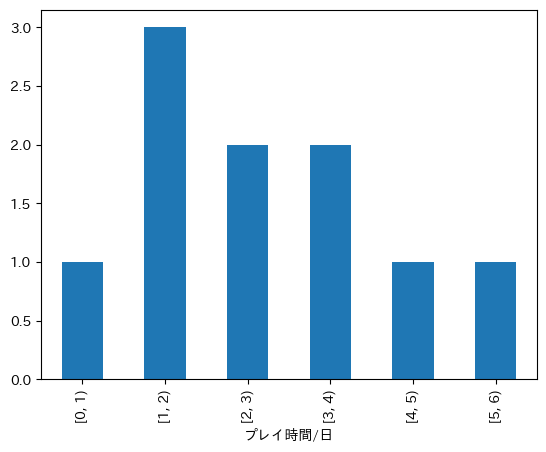

In [ ]:
# ヒストグラムを書く
bin_counts.plot(kind="bar")

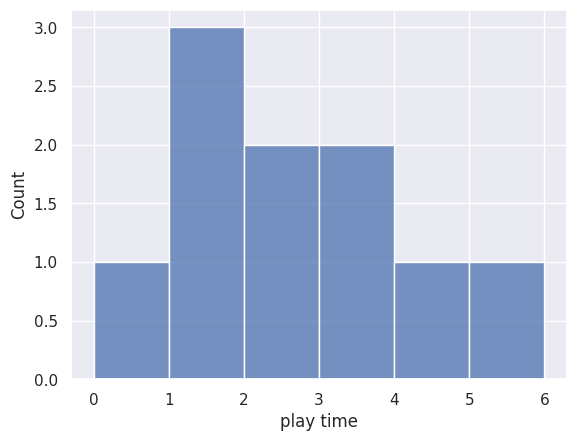

In [ ]:
# seabornを使ってもう少しきれいに
sns.set() # 入れると結果がきれいだが日本語が豆腐になる
ax = sns.histplot(data=play_time, bins=bins)
# 日本語の乱れを回避
ax.set_xlabel("play time")
plt.show()

## 演習
上記の記述を参考に，以下のfarm_sales_dataに含まれる，「総経営耕地面積」の度数分布表とヒストグラムを作成せよ．階級の幅は150とする

補足（advanced）：
* もし余力があれば，この階級の幅は資料にあった階級の幅や数の求め方にあっているか確かめてみよう
* もし余力があれば，教科書を参考にしてカーネル密度推定を描画してみよう
  * この場合は，すべて正の数なので必ずしも利用が適切ではない
  * まずは別のグラフとして出そう（重ねるときは，ヒストグラムの縦軸を割合に変える必要がある）


In [ ]:
farm_sales_data = [
    {"農家番号": 1, "農産物の販売金額": 400, "総経営耕地面積": 60},
    {"農家番号": 2, "農産物の販売金額": 15, "総経営耕地面積": 30},
    {"農家番号": 3, "農産物の販売金額": 480, "総経営耕地面積": 365},
    {"農家番号": 4, "農産物の販売金額": 993, "総経営耕地面積": 190},
    {"農家番号": 5, "農産物の販売金額": 600, "総経営耕地面積": 136},
    {"農家番号": 6, "農産物の販売金額": 150, "総経営耕地面積": 15},
    {"農家番号": 7, "農産物の販売金額": 115, "総経営耕地面積": 37},
    {"農家番号": 8, "農産物の販売金額": 50, "総経営耕地面積": 100},
    {"農家番号": 9, "農産物の販売金額": 0, "総経営耕地面積": 170},
    {"農家番号": 10, "農産物の販売金額": 130, "総経営耕地面積": 70},
    {"農家番号": 11, "農産物の販売金額": 3000, "総経営耕地面積": 783},
    {"農家番号": 12, "農産物の販売金額": 500, "総経営耕地面積": 560},
    {"農家番号": 13, "農産物の販売金額": 200, "総経営耕地面積": 50},
    {"農家番号": 14, "農産物の販売金額": 55, "総経営耕地面積": 35},
    {"農家番号": 15, "農産物の販売金額": 2200, "総経営耕地面積": 595},
    {"農家番号": 16, "農産物の販売金額": 1, "総経営耕地面積": 200},
    {"農家番号": 17, "農産物の販売金額": 900, "総経営耕地面積": 300},
    {"農家番号": 18, "農産物の販売金額": 1000, "総経営耕地面積": 356},
    {"農家番号": 19, "農産物の販売金額": 450, "総経営耕地面積": 155},
    {"農家番号": 20, "農産物の販売金額": 400, "総経営耕地面積": 250}
]

In [ ]:
df_farm = pd.DataFrame(farm_sales_data)
df_farm.head()

,農家番号,農産物の販売金額,総経営耕地面積
0,1,400,60
1,2,15,30
2,3,480,365
3,4,993,190
4,5,600,136


In [ ]:
farm_area = df_farm['総経営耕地面積']
farm_area

,総経営耕地面積
0,60
1,30
2,365
3,190
4,136
5,15
6,37
7,100
8,170
9,70


In [ ]:
# 度数分布表の作成
bins_farm = np.arange(0, 1000, 150)
bin_farm_counts = pd.cut(df_farm['総経営耕地面積'], bins_farm, right=False).value_counts(sort=False)
bin_farm_counts

,count
総経営耕地面積,
"[0, 150)",9
"[150, 300)",5
"[300, 450)",3
"[450, 600)",2
"[600, 750)",0
"[750, 900)",1


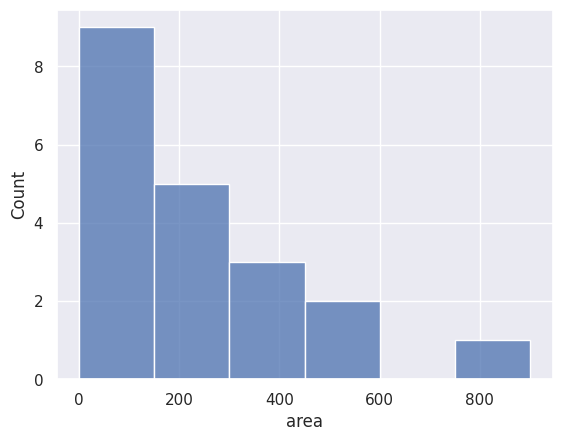

In [ ]:
# ヒストグラムの作成
sns.set() # 入れると結果がきれいだが日本語が豆腐になる
ax = sns.histplot(df_farm['総経営耕地面積'], bins=bins_farm)

# 日本語の乱れを回避
ax.set_xlabel("area")
plt.show()

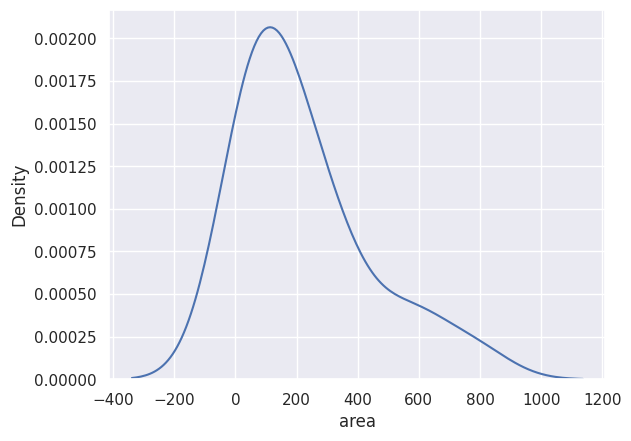

In [ ]:
# カーネル密度推定
ax_kde = sns.kdeplot(df_farm['総経営耕地面積'])

# 日本語の乱れを回避
ax_kde.set_xlabel("area")
plt.show()

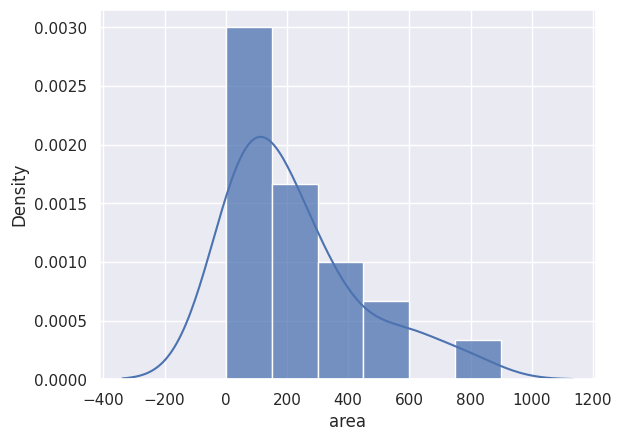

In [ ]:
# ヒストグラムの作成．カーネル密度推定を重ねる
sns.set() # 入れると結果がきれいだが日本語が豆腐になる

# stat="density"で縦軸を割合に統一する
ax = sns.histplot(df_farm['総経営耕地面積'], stat="density", bins=bins_farm)

# カーネル密度推定
sns.kdeplot(df_farm['総経営耕地面積'], ax=ax)

# 日本語の乱れを回避
ax.set_xlabel("area")
plt.show()